In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!pip install -q ultralytics

In [2]:
import ultralytics
print(ultralytics.__version__)

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
!pip install ultralytics

In [ ]:
import ultralytics
print(ultralytics.__version__)

In [3]:
print("merhaba")

import ultralytics
print("sürüm:", ultralytics.__version__)

merhaba


ModuleNotFoundError: No module named 'ultralytics'

In [4]:
import sys

!{sys.executable} -m pip install ultralytics

ERROR: Could not find a version that satisfies the requirement ultralytics (from versions: none)
ERROR: No matching distribution found for ultralytics


In [5]:
import torch
print(torch.cuda.is_available())


True


In [6]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 5.2 MB/s eta 0:00:00


In [7]:
import ultralytics
print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
8.4.161


In [8]:
import glob

yollar = glob.glob("/kaggle/input/**/merged_uav_dataset", recursive=True)
print(yollar)

['/kaggle/input/datasets/umuttuygurr/aerial-uav-thermal-inferred-unified-dataset/merged_uav_dataset']


In [9]:
import os, random

kok = "/kaggle/input/datasets/umuttuygurr/aerial-uav-thermal-inferred-unified-dataset/merged_uav_dataset"
hedef = "/kaggle/working/egitim_verisi"

for bolum, adet in [("train", 3000), ("val", 600)]:
    dosyalar = sorted(os.listdir(kok + "/images/" + bolum))   # o bölümdeki bütün fotoğraflar
    random.seed(42)                                           # her çalıştırmada aynı seçim
    random.shuffle(dosyalar)                                  # karıştır
    secilenler = dosyalar[:adet]                              # ilk 'adet' tanesini al

    os.makedirs(hedef + "/images/" + bolum, exist_ok=True)    # klasörleri oluştur
    os.makedirs(hedef + "/labels/" + bolum, exist_ok=True)

    sayac = 0
    for dosya_adi in secilenler:
        ad = dosya_adi.rsplit(".", 1)[0]                      # uzantıyı at
        etiket = kok + "/labels/" + bolum + "/" + ad + ".txt"
        if os.path.exists(etiket):                            # etiketi olanları al
            os.symlink(kok + "/images/" + bolum + "/" + dosya_adi, hedef + "/images/" + bolum + "/" + dosya_adi)
            os.symlink(etiket, hedef + "/labels/" + bolum + "/" + ad + ".txt")
            sayac = sayac + 1

    print(bolum, sayac)

train 3000
val 600


In [11]:
icerik = """path: /kaggle/working/egitim_verisi
train: images/train
val: images/val

nc: 7
names:
  0: person
  1: car
  2: bicycle
  3: other_vehicle
  4: drone
  5: mine
  6: gun
"""

with open("/kaggle/working/data.yaml", "w") as dosya:
    dosya.write(icerik)

print(icerik)

path: /kaggle/working/egitim_verisi
train: images/train
val: images/val

nc: 7
names:
  0: person
  1: car
  2: bicycle
  3: other_vehicle
  4: drone
  5: mine
  6: gun



In [12]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")          # hazır modelden başla

sonuc = model.train(
    data="/kaggle/working/data.yaml",   # veriyi tanımlayan dosya
    epochs=20,                          # bütün fotoğraflar 20 kez gösterilecek
    imgsz=640,                          # fotoğraflar 640 piksele ölçeklenecek
    batch=32,                           # aynı anda 32 fotoğraf işlenecek
    device=0,                           # 0 = birinci GPU
    project="/kaggle/working/egitim",   # sonuçların kaydedileceği klasör
    name="deneme1",
)

Ultralytics 8.4.161 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=deneme1-2, nbs=64, nms=None, opset=None, optimize=

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/20      4.99G      1.408      1.564      1.206        149        640: 100% ━━━━━━━━━━━━ 94/94 1.8it/s 52.5s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.2it/s 8.1s.5ss
                   all        600       1931      0.781      0.433       0.53       0.29

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/20         5G      1.368      1.358      1.202        120        640: 100% ━━━━━━━━━━━━ 94/94 1.8it/s 52.2s0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.2it/s 8.4s.5s
                   all        600       1931      0.785      0.482      0.585      0.306

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/20         5G      1.356      1.225      1.178        129        640: 100% ━━━━━━━━━━━━ 94/94 1.8it/s 52.1s0.3ss
                 Class     Images  In

In [1]:
import os

print(os.listdir("/kaggle/working"))

['.virtual_documents']


In [2]:
import os, random

kok = "/kaggle/input/datasets/umuttuygurr/aerial-uav-thermal-inferred-unified-dataset/merged_uav_dataset"
hedef = "/kaggle/working/egitim_verisi"

for bolum, adet in [("train", 10000), ("val", 2000)]:     # DEĞİŞTİ: 3000/600 yerine 10000/2000
    dosyalar = sorted(os.listdir(kok + "/images/" + bolum))
    random.seed(42)                                        # aynı tohum → seçim tekrarlanabilir
    random.shuffle(dosyalar)
    secilenler = dosyalar[:adet]

    os.makedirs(hedef + "/images/" + bolum, exist_ok=True)
    os.makedirs(hedef + "/labels/" + bolum, exist_ok=True)

    sayac = 0
    for dosya_adi in secilenler:
        ad = dosya_adi.rsplit(".", 1)[0]
        etiket = kok + "/labels/" + bolum + "/" + ad + ".txt"
        if os.path.exists(etiket):
            os.symlink(kok + "/images/" + bolum + "/" + dosya_adi,
                       hedef + "/images/" + bolum + "/" + dosya_adi)
            os.symlink(etiket, hedef + "/labels/" + bolum + "/" + ad + ".txt")
            sayac = sayac + 1

    print(bolum, sayac)

train 10000
val 2000


In [3]:
icerik = """path: /kaggle/working/egitim_verisi
train: images/train
val: images/val

nc: 7
names:
  0: person
  1: car
  2: bicycle
  3: other_vehicle
  4: drone
  5: mine
  6: gun
"""

with open("/kaggle/working/data.yaml", "w") as dosya:    # "w" = yazma modu
    dosya.write(icerik)

print("data.yaml yazıldı")

data.yaml yazıldı


In [5]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 3.8 MB/s eta 0:00:00


In [6]:
import ultralytics
print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
8.4.162


In [7]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")                      # yine hazır modelden başla (transfer öğrenme)

sonuc = model.train(
    data="/kaggle/working/data.yaml",           # veri tanımı
    epochs=40,                                  # DEĞİŞTİ: 20 → 40
    imgsz=640,                                  # aynı
    batch=32,                                   # aynı
    device=0,                                   # GPU
    project="/kaggle/working/egitim",
    name="deneme2",                             # DEĞİŞTİ: yeni klasör, eskisinin üstüne yazmasın
    patience=15,                                # YENİ: 15 epoch boyunca iyileşme yoksa erken dur
)

Ultralytics 8.4.162 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=deneme2, nbs=64, nms=None, opset=None, optimize=Fa

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/40      5.19G       1.34      1.196      1.157         67        640: 100% ━━━━━━━━━━━━ 313/313 1.4it/s 3:410.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.0it/s 31.6s0.5ss
                   all       2000       6567       0.74      0.589      0.655      0.371

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/40      5.19G      1.325      1.015      1.147         48        640: 100% ━━━━━━━━━━━━ 313/313 1.5it/s 3:300.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.1s/it 35.0s0.5ss
                   all       2000       6567      0.859      0.509      0.604      0.356

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/40      5.19G      1.308     0.9458      1.137         64        640: 100% ━━━━━━━━━━━━ 313/313 1.5it/s 3:350.3ss
                 Class     Im

In [1]:
!pip install -q ultralytics                 # kütüphaneyi kur (oturum sıfırlandıysa gerekli)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 4.7 MB/s eta 0:00:00


In [2]:
import os, random, shutil                   # klasör işlemleri, rastgelelik, dosya kopyalama
import cv2
import numpy as np
from ultralytics import YOLO

print("GPU:", __import__("torch").cuda.is_available())     # True olmalı

kok = "/kaggle/input/datasets/umuttuygurr/aerial-uav-thermal-inferred-unified-dataset/merged_uav_dataset"
hedef = "/kaggle/working/v3_verisi"                        # YENİ klasör: eski eğitimlerle karışmasın

print(os.listdir("/kaggle/working"))                       # şu an neler var, görelim

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
GPU: True
['.virtual_documents']


In [5]:
import shutil

shutil.rmtree(hedef, ignore_errors=True)         # v3_verisi klasörünü tamamen sil
                                                 #   ignore_errors=True → klasör yoksa hata verme
print("silindi, kalanlar:", os.listdir("/kaggle/working"))

silindi, kalanlar: ['.virtual_documents']


In [6]:
import shutil

shutil.rmtree(hedef, ignore_errors=True)                 # varsa eskisini sil → tekrar çalıştırılabilir

for bolum, adet in [("train", 3000), ("val", 600)]:      # v1 ile aynı sayılar
    dosyalar = sorted(os.listdir(kok + "/images/" + bolum))
    random.seed(42)                                      # v1'deki tohumun aynısı
    random.shuffle(dosyalar)                             #   → aynı 3000 fotoğraf seçilir
    secilenler = dosyalar[:adet]

    os.makedirs(hedef + "/images/" + bolum, exist_ok=True)
    os.makedirs(hedef + "/labels/" + bolum, exist_ok=True)

    sayac = 0
    for dosya_adi in secilenler:
        ad = dosya_adi.rsplit(".", 1)[0]
        etiket = kok + "/labels/" + bolum + "/" + ad + ".txt"
        if os.path.exists(etiket):
            os.symlink(kok + "/images/" + bolum + "/" + dosya_adi,
                       hedef + "/images/" + bolum + "/" + dosya_adi)
            os.symlink(etiket,
                       hedef + "/labels/" + bolum + "/" + ad + ".txt")
            sayac = sayac + 1

    print(bolum, sayac)

train 3000
val 600


In [7]:
parcalar_listesi = []                                        # kesilen İHA'lar burada birikecek
tarama_limiti = 800                                          # en fazla bu kadar parça topla
                                                             #   (hepsini taramak gereksiz, zaman alır)

etiket_klasoru = kok + "/labels/train"                       # yalnızca train bölümünü tara
dosyalar = sorted(os.listdir(etiket_klasoru))                # bütün etiket dosyaları
random.seed(1)                                               # tekrarlanabilir olsun
random.shuffle(dosyalar)                                     # karıştır: hep aynı videodan gelmesin

for dosya_adi in dosyalar:                                   # her etiket dosyası için
    if len(parcalar_listesi) >= tarama_limiti:               # yeterince topladıysak
        break                                                #   döngüyü kır

    with open(etiket_klasoru + "/" + dosya_adi) as dosya:
        etiketler = dosya.read().splitlines()

    drone_satirlari = [s for s in etiketler if int(s.split()[0]) == 4]
    #                  ↑ liste üretimi: etiketler içinden sınıfı 4 olanları seç
    #                    "for s in etiketler" + "if ..." tek satırda

    if not drone_satirlari:                                  # drone yoksa fotoğrafı açma
        continue

    ad = dosya_adi.replace(".txt", "")
    foto = cv2.imread(kok + "/images/train/" + ad + ".png")
    if foto is None:                                         # okunamadıysa (uzantı farklı olabilir)
        continue

    yukseklik, genislik = foto.shape[0], foto.shape[1]

    for satir in drone_satirlari:                            # bu fotoğraftaki her İHA
        p = satir.split()
        mx = float(p[1]) * genislik                          # oran → piksel
        my = float(p[2]) * yukseklik
        g  = float(p[3]) * genislik
        y  = float(p[4]) * yukseklik

        x1, y1 = round(mx - g/2), round(my - y/2)            # merkez → köşe
        x2, y2 = round(mx + g/2), round(my + y/2)

        kesit = foto[y1:y2, x1:x2].copy()                    # İHA'yı kes

        if kesit.shape[0] >= 10 and kesit.shape[1] >= 10:    # çok küçükleri alma
            parcalar_listesi.append(kesit)

print("toplanan İHA parçası:", len(parcalar_listesi))

toplanan İHA parçası: 800


In [8]:
# --- arka plan havuzu: gökyüzü OLMAYAN fotoğraflar ---
arka_planlar = []
for dosya_adi in sorted(os.listdir(hedef + "/images/train")):      # eğitim setimizdeki fotoğraflar
    if dosya_adi.startswith("01_uav2uav"):                         # gökyüzü fotoğraflarını ATLA
        continue                                                   #   amacımız BAŞKA bağlamlar
    arka_planlar.append(dosya_adi.rsplit(".", 1)[0])               # uzantısız adı ekle

print("arka plan havuzu:", len(arka_planlar))


# --- üretim ---
random.seed(7)                                                     # tekrarlanabilirlik
uretilecek = 1500                                                  # kaç yapay fotoğraf
uretilen = 0

for i in range(uretilecek):                                        # 1500 kez dön
    ad = random.choice(arka_planlar)                               # rastgele bir arka plan seç

    foto = cv2.imread(hedef + "/images/train/" + ad + ".png")      # arka planı oku
    if foto is None:
        continue
    yukseklik, genislik = foto.shape[0], foto.shape[1]

    with open(hedef + "/labels/train/" + ad + ".txt") as dosya:
        satirlar = dosya.read().splitlines()                       # arka planın KENDİ etiketleri
                                                                   #   korunuyor, siliniyor değil

    yapay = foto.copy()                                            # üstünde çalışacağımız kopya

    for _ in range(random.randint(1, 3)):                          # 1-3 arası İHA yapıştır
        kesit = random.choice(parcalar_listesi)                    # 800 parçadan rastgele biri

        olcek = random.uniform(0.6, 1.8)                           # boyutu rastgele değiştir
        yeni_g = max(12, int(kesit.shape[1] * olcek))              # yeni genişlik (en az 12 px)
        yeni_y = max(12, int(kesit.shape[0] * olcek))              # yeni yükseklik
        if yeni_g >= genislik or yeni_y >= yukseklik:              # arka plandan büyükse
            continue                                               #   bu İHA'yı atla

        kesit = cv2.resize(kesit, (yeni_g, yeni_y))                # boyutlandır (genişlik, yükseklik)

        x = random.randint(0, genislik - yeni_g - 1)               # rastgele konum
        y = random.randint(0, yukseklik - yeni_y - 1)

        yapay[y:y+yeni_y, x:x+yeni_g] = kesit                      # yapıştır

        merkez_x = (x + yeni_g / 2) / genislik                     # piksel → oran
        merkez_y = (y + yeni_y / 2) / yukseklik
        oran_g   = yeni_g / genislik
        oran_y   = yeni_y / yukseklik
        satirlar.append(f"4 {merkez_x:.6f} {merkez_y:.6f} {oran_g:.6f} {oran_y:.6f}")
                                                                   # 4 = drone

    yeni_ad = f"yapay_{i:05d}"                                     # "yapay_00000", "yapay_00001"...
                                                                   #   :05d → 5 haneli, başı sıfırlı

    cv2.imwrite(hedef + "/images/train/" + yeni_ad + ".png", yapay)  # fotoğrafı KAYDET
                                                                     #   (kısayol değil, gerçek dosya)

    with open(hedef + "/labels/train/" + yeni_ad + ".txt", "w") as dosya:
        dosya.write("\n".join(satirlar) + "\n")                    # etiketleri yaz
                                                                   #   "\n".join → satırları
                                                                  #   alt alta birleştirir

    uretilen = uretilen + 1

print("üretilen yapay fotoğraf:", uretilen)
print("eğitim setindeki toplam fotoğraf:", len(os.listdir(hedef + "/images/train")))


arka plan havuzu: 2575
üretilen yapay fotoğraf: 1500
eğitim setindeki toplam fotoğraf: 4500


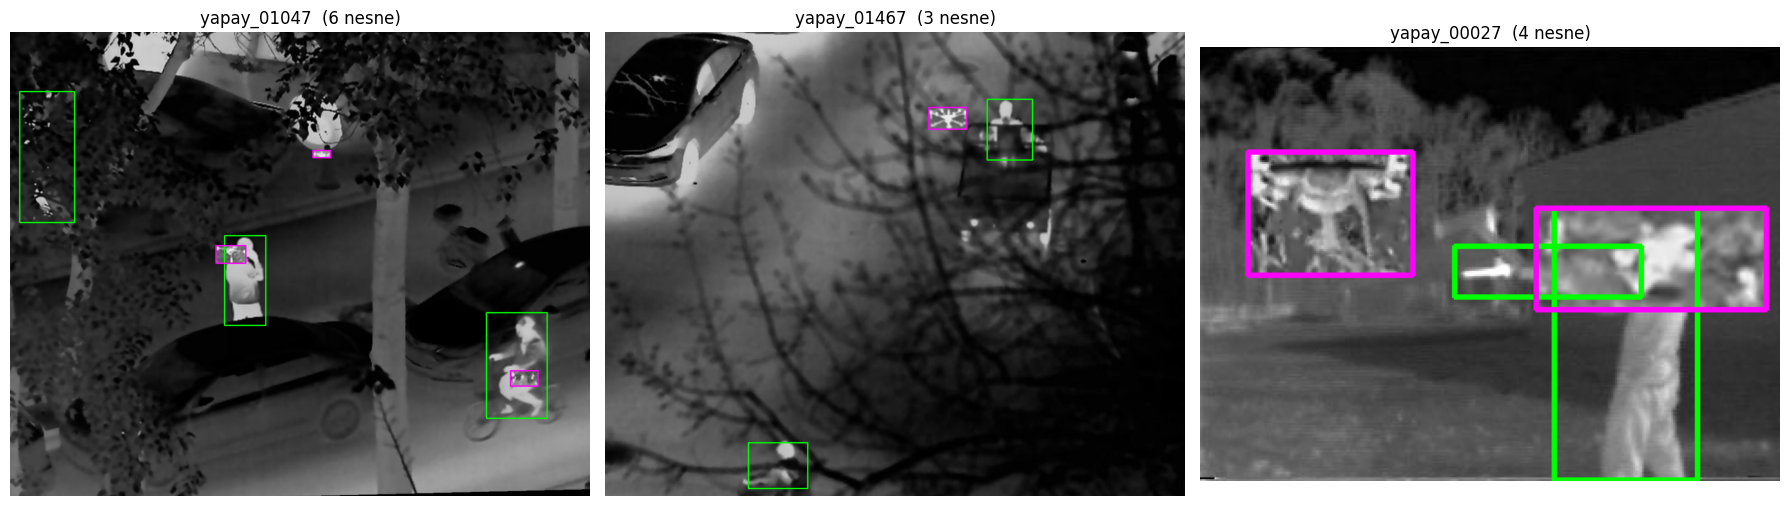

In [9]:
import matplotlib.pyplot as plt

fig, eksenler = plt.subplots(1, 3, figsize=(18, 5))

for eksen in eksenler:
    no = random.randint(0, 1499)                              # rastgele bir yapay fotoğraf numarası
    ad = f"yapay_{no:05d}"

    foto = cv2.imread(hedef + "/images/train/" + ad + ".png")  # yapay fotoğrafı oku
    h, w = foto.shape[0], foto.shape[1]

    with open(hedef + "/labels/train/" + ad + ".txt") as dosya:
        satirlar = dosya.read().splitlines()                   # etiketlerini oku

    cizim = foto.copy()
    for satir in satirlar:                                     # her etiket satırı için
        p = satir.split()
        numara = int(p[0])                                     # sınıf numarası
        mx, my = float(p[1]) * w, float(p[2]) * h              # oran → piksel
        g, y_ = float(p[3]) * w, float(p[4]) * h
        renk = (255, 0, 255) if numara == 4 else (0, 255, 0)   # drone mor, diğerleri yeşil
        cv2.rectangle(cizim,
                      (round(mx - g/2), round(my - y_/2)),     # sol üst köşe
                      (round(mx + g/2), round(my + y_/2)),     # sağ alt köşe
                      renk, 2)

    eksen.imshow(cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB))
    eksen.set_title(f"{ad}  ({len(satirlar)} nesne)")
    eksen.axis("off")

plt.tight_layout()
plt.show()


In [10]:
icerik = """path: /kaggle/working/v3_verisi
train: images/train
val: images/val

nc: 7
names:
  0: person
  1: car
  2: bicycle
  3: other_vehicle
  4: drone
  5: mine
  6: gun
"""

with open("/kaggle/working/data_v3.yaml", "w") as dosya:   # yeni dosya adı, eskisiyle karışmasın
    dosya.write(icerik)

print("yazıldı")

yazıldı


In [11]:
model = YOLO("yolo11n.pt")                      # v1 ile aynı başlangıç noktası

sonuc = model.train(
    data="/kaggle/working/data_v3.yaml",        # yapay veri dahil eğitim seti
    epochs=20,                                  # v1 ile AYNI
    imgsz=640,                                  # v1 ile aynı
    batch=32,                                   # v1 ile aynı
    device=0,
    project="/kaggle/working/egitim",
    name="deneme3_yapay",                       # yeni klasör
)

Ultralytics 8.4.164 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_v3.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=deneme3_yapay, nbs=64, nms=None, opset=None, optimize=False,

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/20      4.64G       1.27      1.322       1.14        198        640: 100% ━━━━━━━━━━━━ 141/141 1.9it/s 1:130.3sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.3it/s 7.8s.5ss
                   all        600       1931      0.781      0.463      0.545      0.301

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/20      4.64G      1.255      1.141      1.127        117        640: 100% ━━━━━━━━━━━━ 141/141 1.9it/s 1:130.3sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.3it/s 7.7s.5ss
                   all        600       1931      0.742       0.44       0.52      0.295

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/20      4.64G      1.237      1.048      1.121        133        640: 100% ━━━━━━━━━━━━ 141/141 1.9it/s 1:130.3sss
                 Class     Ima